# **Part 1 — Task 1: Dataset Understanding**

In [250]:
import pandas as pd
import numpy as np

In [251]:
df = pd.read_csv("customer_churn_nn.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [252]:
df.head()  # View Dataset

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [253]:
print("Dataset shape:", df.shape)   # Dataset Shape (Rows & Columns)

Dataset shape: (2000, 17)


In [254]:
print(df.dtypes)  # Type of input features

customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [255]:
print(df.isnull().sum()) # Missing Value Check

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [256]:
df.describe()   # Basic statistical summary

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [257]:
df["churn"].value_counts() # Distribution of the target variable

,count
churn,
0,1969
1,31


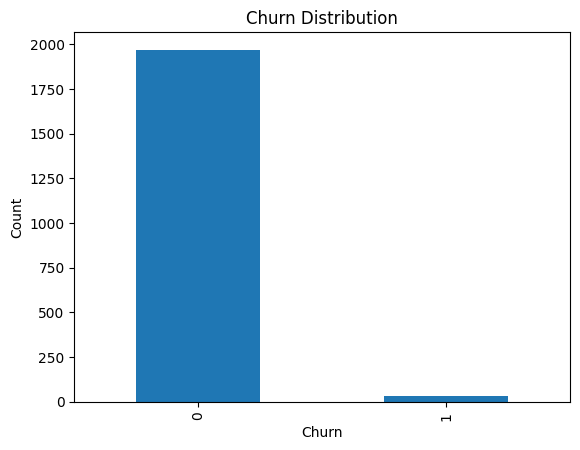

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns

df["churn"].value_counts().plot(kind="bar")

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

([0, 1, 2],
 [Text(0, 0, 'Month-to-month'),
  Text(1, 0, 'One-year'),
  Text(2, 0, 'Two-year')])

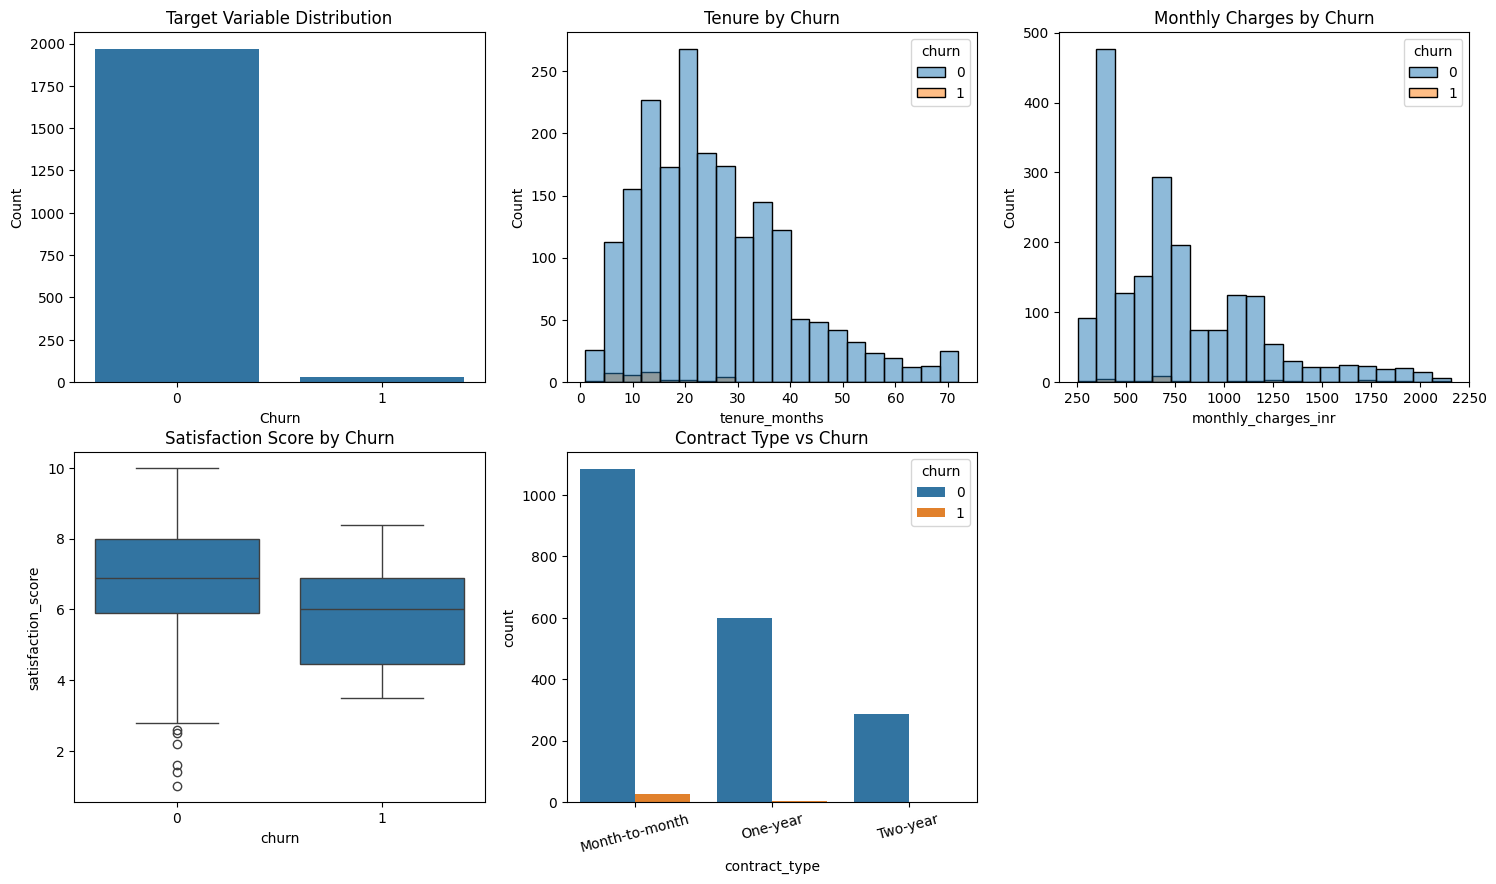

In [281]:
plt.figure(figsize=(18, 10))

# Target Variable Distribution
plt.subplot(2, 3, 1)

sns.countplot(x='churn', data=df)

plt.title('Target Variable Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')

#Tenure Distribution by Churn

plt.subplot(2, 3, 2)

sns.histplot(data=df, x='tenure_months', hue='churn', bins=20)

plt.title('Tenure by Churn')

# Monthly Charges Distribution
plt.subplot(2, 3, 3)

sns.histplot(data=df, x='monthly_charges_inr', hue='churn', bins=20)

plt.title('Monthly Charges by Churn')

#Satisfaction Score Boxplot

plt.subplot(2, 3, 4)

sns.boxplot(x='churn', y='satisfaction_score', data=df)

plt.title('Satisfaction Score by Churn')

# Contract Type vs Churn

plt.subplot(2, 3, 5)

sns.countplot(x='contract_type', hue='churn', data=df)

plt.title('Contract Type vs Churn')

plt.xticks(rotation=15)


# **Task 2: Data Preprocessing**

Missing value analysis was performed using df.isnull().sum(). No missing values were found in the dataset, therefore no missing value handling or imputation was required during preprocessing.

In [259]:
# Drop Identifier Column - Customer_id is an identifier column, it will not provide any learning pattern.

df = df.drop("customer_id", axis=1)

print("customer_id column removed")

customer_id column removed


In [260]:
# Seperating Features and target

X = df.drop("churn", axis=1)

y = df["churn"]

print("Features and target separated")

Features and target separated


In [261]:
# Encoding categorical columns

# One hot Encoding using get_dummies funtion of pandas
# I have not used label encoding here because neural networks may think categories have order

X = pd.get_dummies(X, drop_first=True)  # drop_first=True ---- To avoid dummy variable trap

print("Categorical columns encoded")

Categorical columns encoded


In [262]:
# Scaling or normalizing numerical features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Features scaled successfully")


Features scaled successfully


In [263]:
# Splitting the dataset into training and testing sets

# Cross-validation could further improve reliability of model evaluation. However, for this assignment, a standard train-test split approach was used for simplicity and computational efficiency.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # To ensure that both training and testing datasets maintain a similar proportion of churn and non-churn classes.
)
# Churn distribution is highly imbalanced
# Stratified train-test splitting was used to ensure that both training and testing datasets maintained a similar proportion of churn and non-churn classes.
print("Train-test split completed")

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

Train-test split completed
(1600, 24)
(400, 24)
(1600,)
(400,)


# **Task 3 — Neural Network Model Building**

In [264]:
import tensorflow as tf

from tensorflow.keras.models import Sequential  # for layer-by-layer model
from tensorflow.keras.layers import Dense  # for fully connected layer

**Input Features ---> Hidden Layer (16 neurons, ReLU(WX+b)---->Output Layer (1 neuron, Sigmoid).**

In [265]:
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Dense layer internally applies linear transformation (WX + b) before activation.
# ReLU activation introduces non-linearity by converting negative values to 0.
# ELU is similar to ReLU but allows small negative outputs, helping reduce dead neuron problems.
# A single hidden layer was initially used because the dataset is structured and moderately complex. The number of neurons was selected experimentally and later varied during hyperparameter tuning to study its effect on model performance.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [266]:
model.add(Dense(1, activation='sigmoid'))

# Output layer uses 1 neuron because this is a binary classification problem.
# Sigmoid activation converts output into probability values between 0 and 1.

In [267]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Adam optimizer updates weights efficiently during training.
# Binary crossentropy is used because this is a binary classification problem.
# Accuracy is used to monitor prediction performance during training.

In [268]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2398 - loss: 1.1374 - val_accuracy: 0.3438 - val_loss: 0.9033
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4594 - loss: 0.7874 - val_accuracy: 0.6406 - val_loss: 0.6312
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7344 - loss: 0.5531 - val_accuracy: 0.8813 - val_loss: 0.4524
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9117 - loss: 0.4021 - val_accuracy: 0.9594 - val_loss: 0.3355
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9711 - loss: 0.3055 - val_accuracy: 0.9812 - val_loss: 0.2562
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9797 - loss: 0.2415 - val_accuracy: 0.9937 - val_loss: 0.2020
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9812 - loss: 0.1981 - val_accuracy: 0.9937 - val_loss: 0.1644
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9820 - loss: 0.1685 - val_accuracy: 0.9937 - val_loss:

# **Task 4: Training and Evaluation**

In [269]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


# Note ---- fit(), evaluate(), and predict() automatically handle training/evaluation modes internally.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9850 - loss: 0.0740
Test Loss: 0.07399094104766846
Test Accuracy: 0.9850000143051147


The neural network model gave low testing accuracy. One possible reason is that the dataset is highly imbalanced because the number of churned customers is very small compared to non-churned customers. Due to this, the model may not learn churn patterns properly. Further tuning of parameters and experimenting with different network architectures may help improve the model performance.

In [270]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)   # The model first predicts churn probabilities between 0 and 1.

y_pred = (y_pred_prob > 0.5).astype(int)  # # Probabilities above 0.5 are classified as churn (1), otherwise non-churn (0).


# Confusion matrix


cm = confusion_matrix(y_test, y_pred)

print(cm)

# Confusion matrix helps analyze correct and incorrect predictions for each class.
# It is especially useful for imbalanced classification problems.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
[[394   0]
 [  6   0]]


Although the model achieved high accuracy, the confusion matrix showed that it failed to correctly predict churned customers. The model predicted almost all customers as non-churn, which happened because the dataset is highly imbalanced. This demonstrates that accuracy alone is not sufficient for evaluating imbalanced classification problems.

In [271]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The classification report showed that the model performed very well for non-churn customers but failed to correctly identify churn customers. Although the overall accuracy was high, the precision, recall, and F1-score for the churn class were all zero. This happened because the dataset is highly imbalanced, causing the model to become biased toward the majority class. Therefore, the confusion matrix and classification report provided a more realistic evaluation than accuracy alone.

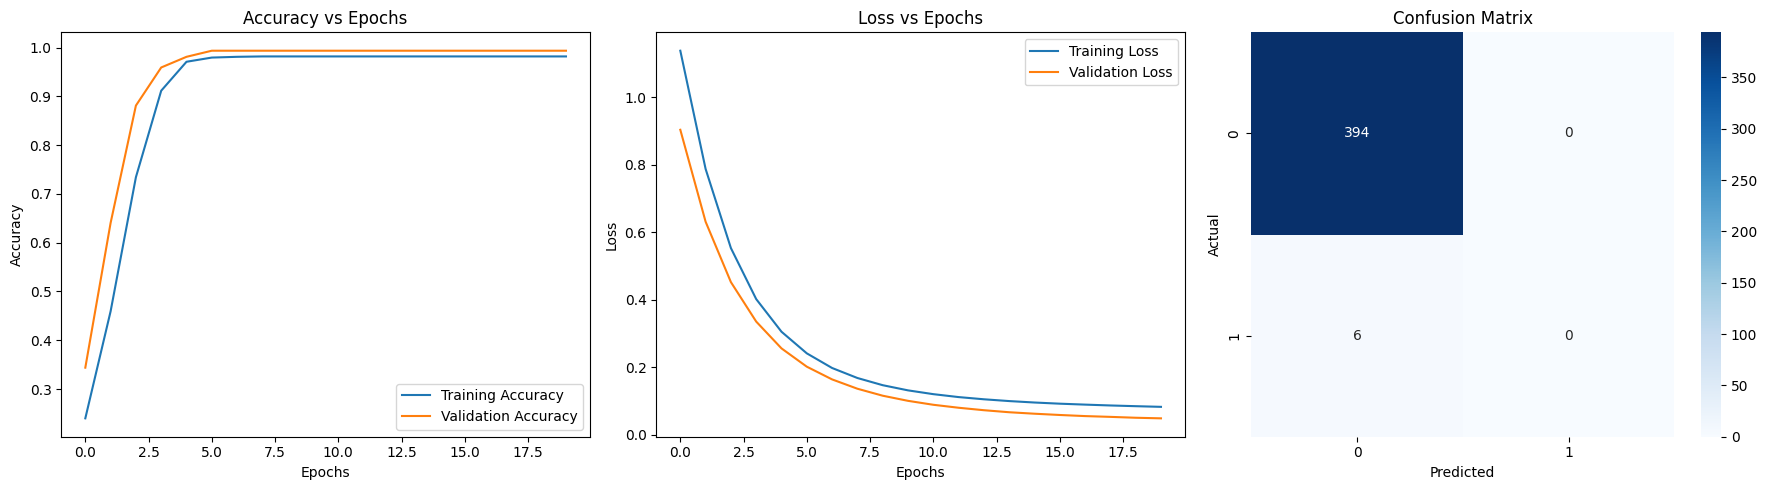

In [272]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))


# Accuracy Plot
plt.subplot(1, 3, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

# Loss Plot
plt.subplot(1, 3, 2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()



# Confusion Matrix Heatmap

plt.subplot(1, 3, 3)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()

plt.savefig("evaluation_outputs.png")

plt.show()

In [273]:
plt.tight_layout()

plt.savefig("evaluation_outputs.png")

plt.show()

<Figure size 640x480 with 0 Axes>

# **Task 5: Hyperparameter Experimentation**

In [274]:
from tensorflow.keras.optimizers import Adam

def build_and_train_model(
    hidden_layers=1,
    neurons=16,
    activation='relu',
    learning_rate=0.001,
    epochs=20
):

    model = Sequential()

    # First hidden layer
    model.add(Dense(neurons, activation=activation, input_shape=(X_train.shape[1],)))

    # Optional second hidden layer
    if hidden_layers == 2:
        model.add(Dense(8, activation=activation))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Optimizer with custom learning rate
    optimizer = Adam(learning_rate=learning_rate)

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Train model
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    # Evaluate model
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    return history, test_loss, test_accuracy

In [275]:
results = []

# Experiment 1 — Baseline Model
# 1 hidden layer, 16 neurons, ReLU activation, learning rate 0.001, 20 epochs

history1, loss1, acc1 = build_and_train_model(
    hidden_layers=1,
    neurons=16,
    activation='relu',
    learning_rate=0.001,
    epochs=20
)

results.append([
    "Exp 1",
    "1 Hidden Layer",
    16,
    "ReLU",
    0.001,
    20,
    loss1,
    acc1
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [276]:
# Experiment 2 — Two Hidden Layers
# Added second hidden layer to study effect of deeper architecture

history2, loss2, acc2 = build_and_train_model(
    hidden_layers=2,
    neurons=16,
    activation='relu',
    learning_rate=0.001,
    epochs=20
)

results.append([
    "Exp 2",
    "2 Hidden Layers",
    16,
    "ReLU",
    0.001,
    20,
    loss2,
    acc2
])

In [277]:
# Experiment 3 — ELU Activation with More Neurons
# Increased neurons to 32 and used ELU activation for comparison

history3, loss3, acc3 = build_and_train_model(
    hidden_layers=1,
    neurons=32,
    activation='elu',
    learning_rate=0.001,
    epochs=20
)

results.append([
    "Exp 3",
    "1 Hidden Layer",
    32,
    "ELU",
    0.001,
    20,
    loss3,
    acc3
])

In [278]:
# Experiment 4 — Higher Learning Rate
# Increased learning rate from 0.001 to 0.01 to study optimization behavior

history4, loss4, acc4 = build_and_train_model(
    hidden_layers=1,
    neurons=16,
    activation='relu',
    learning_rate=0.01,
    epochs=20
)

results.append([
    "Exp 4",
    "1 Hidden Layer",
    16,
    "ReLU",
    0.01,
    20,
    loss4,
    acc4
])

In [279]:
# Experiment 5 — More Training Epochs
# Increased epochs from 20 to 50 to study effect of longer training

history5, loss5, acc5 = build_and_train_model(
    hidden_layers=1,
    neurons=16,
    activation='relu',
    learning_rate=0.001,
    epochs=50
)

results.append([
    "Exp 5",
    "1 Hidden Layer",
    16,
    "ReLU",
    0.001,
    50,
    loss5,
    acc5
])

In [280]:
# Converting Results into DataFrame

results_df = pd.DataFrame(
    results,
    columns=[
        "Experiment",
        "Architecture",
        "Neurons",
        "Activation",
        "Learning Rate",
        "Epochs",
        "Test Loss",
        "Test Accuracy"
    ]
)

results_df.to_csv("model_comparison_table.csv", index=False)
results_df

,Experiment,Architecture,Neurons,Activation,Learning Rate,Epochs,Test Loss,Test Accuracy
0,Exp 1,1 Hidden Layer,16,ReLU,0.001,20,0.078917,0.9850
1,Exp 2,2 Hidden Layers,16,ReLU,0.001,20,0.061933,0.9850
2,Exp 3,1 Hidden Layer,32,ELU,0.001,20,0.055307,0.9850
3,Exp 4,1 Hidden Layer,16,ReLU,0.010,20,0.089301,0.9825
4,Exp 5,1 Hidden Layer,16,ReLU,0.001,50,0.064786,0.9850


Different neural network experiments were conducted by changing hidden layers, number of neurons, activation functions, learning rate, and epochs. The results showed that increasing epochs and using ELU activation slightly improved model performance by reducing loss values. Increasing the learning rate resulted in slightly poorer performance, indicating less stable optimization. Overall, Experiment 5 achieved the best performance with the lowest loss and highest testing accuracy.

# **Task 6: Final Reflection**

1. What role do weights and biases play in the model?

  Weights and biases are the main learnable parameters of a neural network. Weights determine the importance of input features and control how strongly inputs influence the output. Bias helps shift the activation function and allows the model to fit the data more flexibly. During training, the neural network continuously updates weights and biases using backpropagation and optimization algorithms to reduce prediction error.

2. Why is an activation function required?

 Activation functions introduce non-linearity into the neural network. Without activation functions, the neural network would behave like a simple linear model and would not be able to learn complex patterns from the data. Functions like ReLU and ELU help the network learn meaningful relationships between input features and target variables.

3. What happens when learning rate is too high or too low?

  The learning rate controls how much the model updates its weights during training. If the learning rate is too high, the model may overshoot the optimal solution and training may become unstable. If the learning rate is too low, training becomes very slow and the model may take a long time to converge. Therefore, selecting an appropriate learning rate is important for stable and efficient learning.

4. Did your model show signs of underfitting or overfitting?

The model did not show strong signs of overfitting because the training and testing accuracies were very similar. However, the classification report and confusion matrix revealed that the model struggled to correctly identify churn customers due to severe class imbalance in the dataset. This indicates that the main challenge was class imbalance rather than traditional underfitting or overfitting.

